In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

# List contents of My Drive to locate the zip file
drive_path = '/content/drive/MyDrive'
if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"'{drive_path}' does not exist. Please ensure Google Drive is mounted correctly.")

Contents of '/content/drive/MyDrive':
LPU
Colab Notebooks
Classroom
archive
CICIDS 2017.zip
CIC-IDS 2017
Untitled folder
CICIDS2017
CICIDS2017_compressed.csv
label_encoder.save
scaler.save


In [3]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [7]:
import pandas as pd
import numpy as np
import zipfile, os
import shutil # Import shutil for rmtree

# Paths
zip_path = "/content/drive/MyDrive/CICIDS 2017.zip" # Corrected zip file name
extract_path = "/content/CICIDS2017"
output_csv = "/content/drive/MyDrive/CICIDS2017.csv"

# Ensure the extraction directory is clean before extraction
if os.path.exists(extract_path):
    print(f"Removing existing extraction directory: '{extract_path}'")
    shutil.rmtree(extract_path)

# Extract ZIP
if os.path.exists(zip_path):
    print(f"Extracting {zip_path} to {extract_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print(f"Error: Zip file not found at '{zip_path}'. Please check the path and ensure it's mounted correctly.")

# Verify extracted files
extracted_files = [f for f in os.listdir(extract_path) if f.endswith(".csv")]
if not extracted_files:
    print(f"Error: No CSV files found in '{extract_path}' after extraction. Directory contents: {os.listdir(extract_path) if os.path.exists(extract_path) else 'Directory does not exist'}")
else:
    print(f"Found {len(extracted_files)} CSV files in '{extract_path}'.")
    print(f"First 5 extracted CSV files: {extracted_files[:5]}")

# Read and merge CSV files
csv_files = [os.path.join(extract_path, f)
             for f in os.listdir(extract_path) if f.endswith(".csv")]

# Only proceed with concatenation if csv_files is not empty
if csv_files:
    df_list = [pd.read_csv(f) for f in csv_files]
    data = pd.concat(df_list, ignore_index=True)

    # Clean column names
    data.columns = data.columns.str.strip()

    # Remove NaN and Infinite values
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)

    # Save the full dataset (removed sampling step)
    data.to_csv(output_csv, index=False) # Saving full 'data' instead of 'reduced_data'

    print("Dataset saved!")
    print("Shape:", data.shape)
else:
    print("No CSV files found to concatenate. Data processing skipped.")

Removing existing extraction directory: '/content/CICIDS2017'
Extracting /content/drive/MyDrive/CICIDS 2017.zip to /content/CICIDS2017...
Extraction complete.
Error: No CSV files found in '/content/CICIDS2017' after extraction. Directory contents: ['CIC-IDS 2017']
No CSV files found to concatenate. Data processing skipped.


In [9]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/CICIDS2017_compressed.csv")
print("Dataset shape:", data.shape)
print("\nLabel distribution:\n", data['Label'].value_counts())

Dataset shape: (134603, 79)

Label distribution:
 Label
BENIGN                        50000
PortScan                      15000
DoS Hulk                      15000
DDoS                          15000
DoS GoldenEye                 10293
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64


In [10]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,11997,3,1,18,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
1,9099,68,1,1,2,6,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
2,80,55963607,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,56000000.0,0.0,56000000,56000000,DoS GoldenEye
3,21,9870701,9,15,106,188,23,0,11.777778,9.444281,...,32,0.0,0.0,0,0,0.0,0.0,0,0,FTP-Patator
4,53458,32791,6,1,453,6,305,6,75.500000,114.227405,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [11]:
#pd.read_csv(, encoding="ISO-8859-1")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134603 entries, 0 to 134602
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             134603 non-null  int64  
 1   Flow Duration                134603 non-null  int64  
 2   Total Fwd Packets            134603 non-null  int64  
 3   Total Backward Packets       134603 non-null  int64  
 4   Total Length of Fwd Packets  134603 non-null  int64  
 5   Total Length of Bwd Packets  134603 non-null  int64  
 6   Fwd Packet Length Max        134603 non-null  int64  
 7   Fwd Packet Length Min        134603 non-null  int64  
 8   Fwd Packet Length Mean       134603 non-null  float64
 9   Fwd Packet Length Std        134603 non-null  float64
 10  Bwd Packet Length Max        134603 non-null  int64  
 11  Bwd Packet Length Min        134603 non-null  int64  
 12  Bwd Packet Length Mean       134603 non-null  float64
 13 

In [12]:
# Strip column names
data.columns = data.columns.str.strip()

print("Missing values:", data.isnull().sum().sum())


Missing values: 0


In [13]:
data.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [14]:
data.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [15]:
X = data.drop(columns=['Label'])
y = data['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (134603, 78)
y shape: (134603,)


In [16]:
y = y.str.replace("�", "-", regex=False)


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels example:", y_encoded[:10])


Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']
Encoded labels example: [ 4 10  3  7  0 10  4  0  0  0]


In [18]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Convert to numpy
X_values = X.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

print("Scaled feature shape:", X_scaled.shape)
print("Sample scaled values:\n", X_scaled[:2])



Scaled feature shape: (134603, 78)
Sample scaled values:
 [[-3.33776117e-01 -5.51279841e-01 -4.96603806e-02 -5.96613841e-02
  -3.61119712e-02 -3.19428808e-02 -2.89610903e-01 -8.35105406e-02
  -2.49679155e-01 -2.84730095e-01 -5.35730946e-01 -3.75279230e-01
  -5.67956594e-01 -5.06403649e-01 -5.03009335e-02 -2.58287675e-01
  -3.21366684e-01 -4.39081724e-01 -4.90014670e-01 -1.23126366e-01
  -5.33574078e-01 -3.32081275e-01 -4.23152344e-01 -4.84483556e-01
  -1.78239515e-01 -3.65421782e-01 -2.43891568e-01 -2.60756102e-01
  -3.08878868e-01 -1.50758267e-01 -2.74223085e-01  0.00000000e+00
  -6.09488757e-03  0.00000000e+00  2.89011344e-03  2.88664148e-03
  -2.35142845e-01 -1.92639305e-01 -3.51060613e-01 -5.48708366e-01
  -5.99753217e-01 -5.49904280e-01 -4.09188580e-01  5.20810147e+00
  -2.74223085e-01 -1.21904544e-02 -9.13552497e-01 -7.28140195e-01
  -2.89503752e-01 -6.09488757e-03 -1.21904544e-02 -9.49467296e-01
  -6.00056171e-01 -2.49679155e-01 -5.67956594e-01  2.89011344e-03
   0.00000000e+00 

In [19]:
import joblib
joblib.dump(scaler, "/content/drive/MyDrive/scaler.save") # scaled values saved

['/content/drive/MyDrive/scaler.save']

In [20]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (107682, 78)
Testing set shape: (26921, 78)


In [21]:
# Reshape for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("CNN Train shape:", X_train_cnn.shape)
print("CNN Test shape:", X_test_cnn.shape)


CNN Train shape: (107682, 78, 1)
CNN Test shape: (26921, 78, 1)


In [22]:
# Updated Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(label_encoder.classes_)

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 76, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 36, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,447 (1.29 MB)

 Trainable params: 338,447 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Updated Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-5
)

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.8690 - loss: 0.4318 - val_accuracy: 0.9506 - val_loss: 0.1821 - learning_rate: 0.0010
Epoch 2/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.9535 - loss: 0.1533 - val_accuracy: 0.9643 - val_loss: 0.1166 - learning_rate: 0.0010
Epoch 3/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.9610 - loss: 0.1221 - val_accuracy: 0.9660 - val_loss: 0.1076 - learning_rate: 0.0010
Epoch 4/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.9647 - loss: 0.1069 - val_accuracy: 0.9690 - val_loss: 0.0943 - learning_rate: 0.0010
Epoch 5/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.9673 - loss: 0.0945 - val_accuracy: 0.9676 - val_loss: 0.0948 - learning_rate: 0.0010
Epoch 6/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step - accuracy: 0.9696 - loss: 0.0870 - val_accuracy: 0.9730 - val_loss: 0.0850 - learning_rate: 0.0010
Epoch 7/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.9704 - l

In [24]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 98.38%
Test Loss: 0.0461


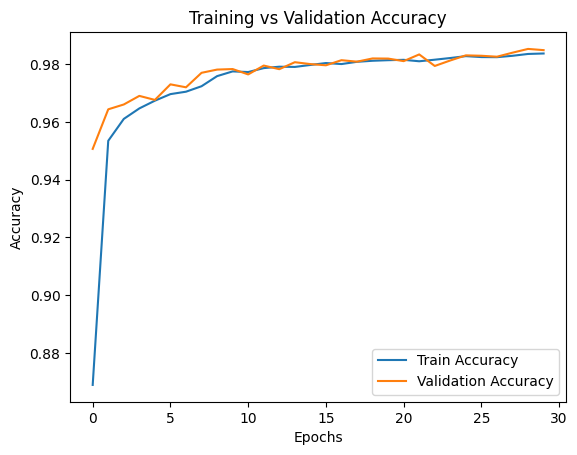

In [25]:
# 99.72%
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


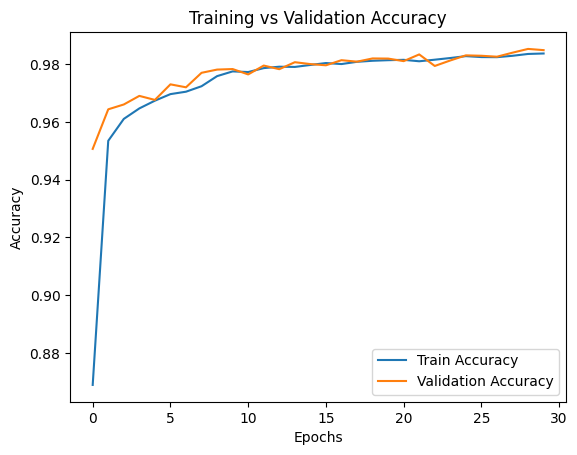

In [26]:
# 99.72%
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

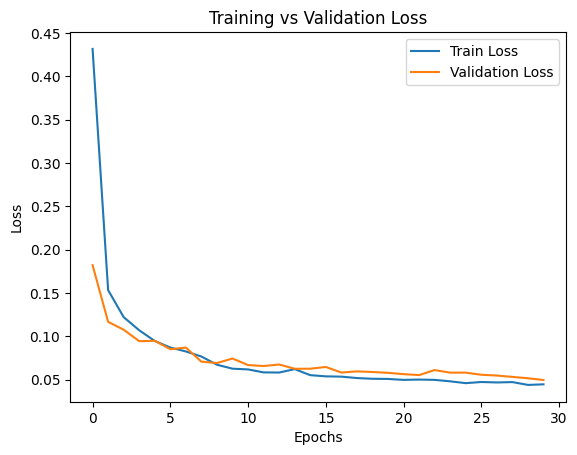

In [27]:
# 99.72%
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


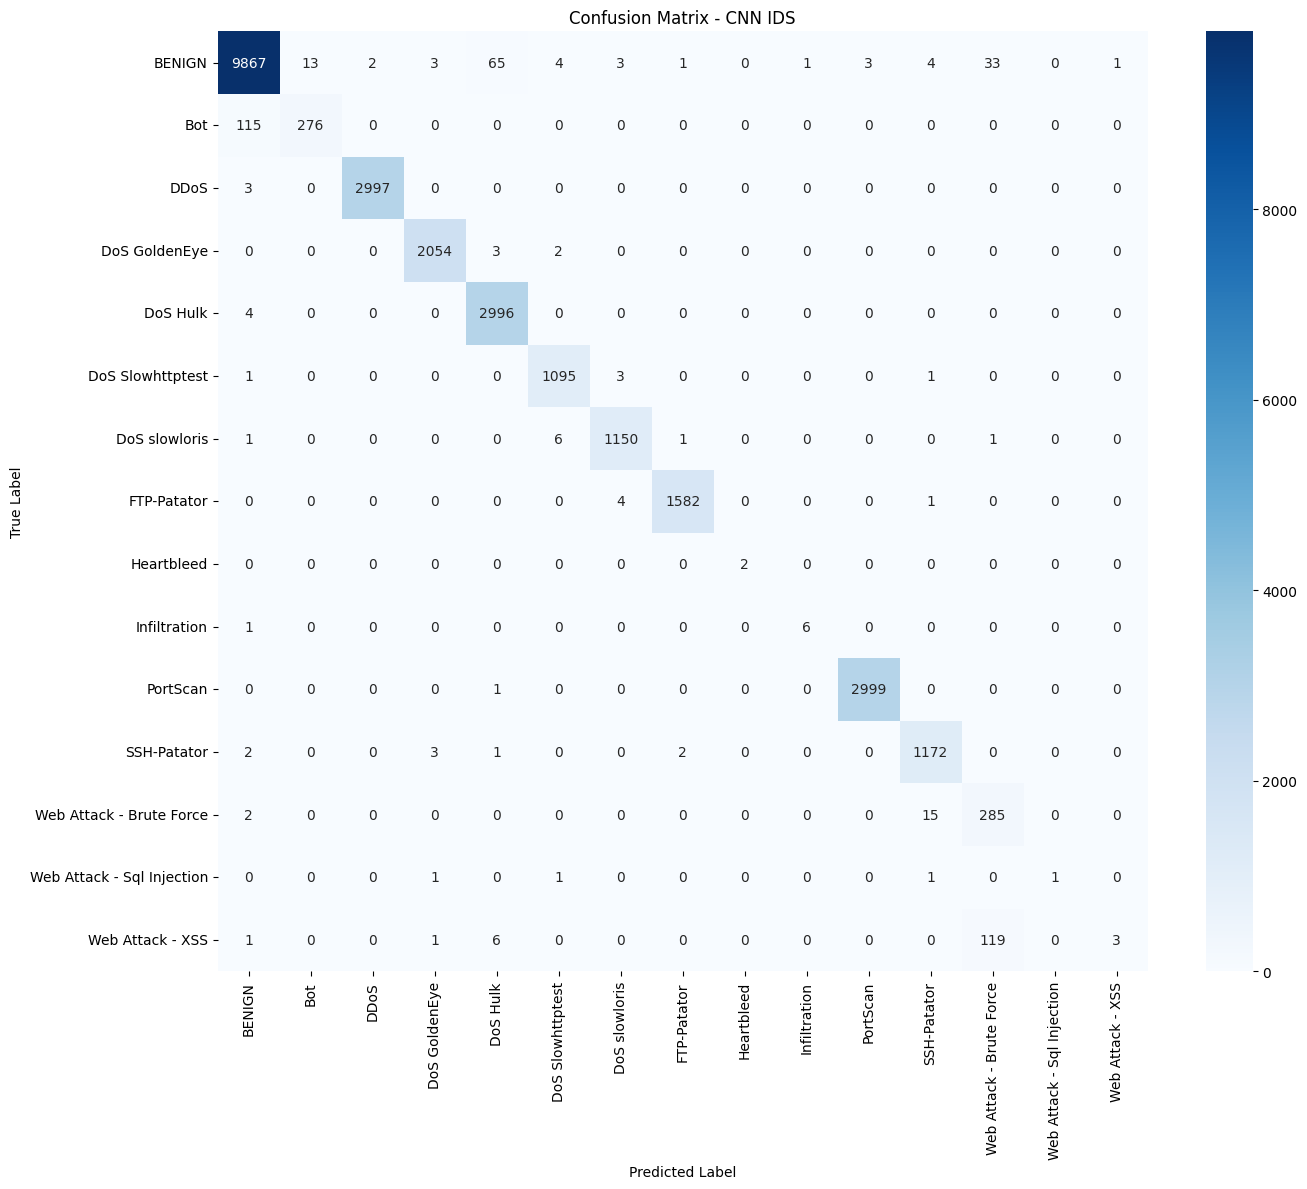

In [28]:
# 99.72%
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - CNN IDS')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


<Figure size 1500x700 with 0 Axes>

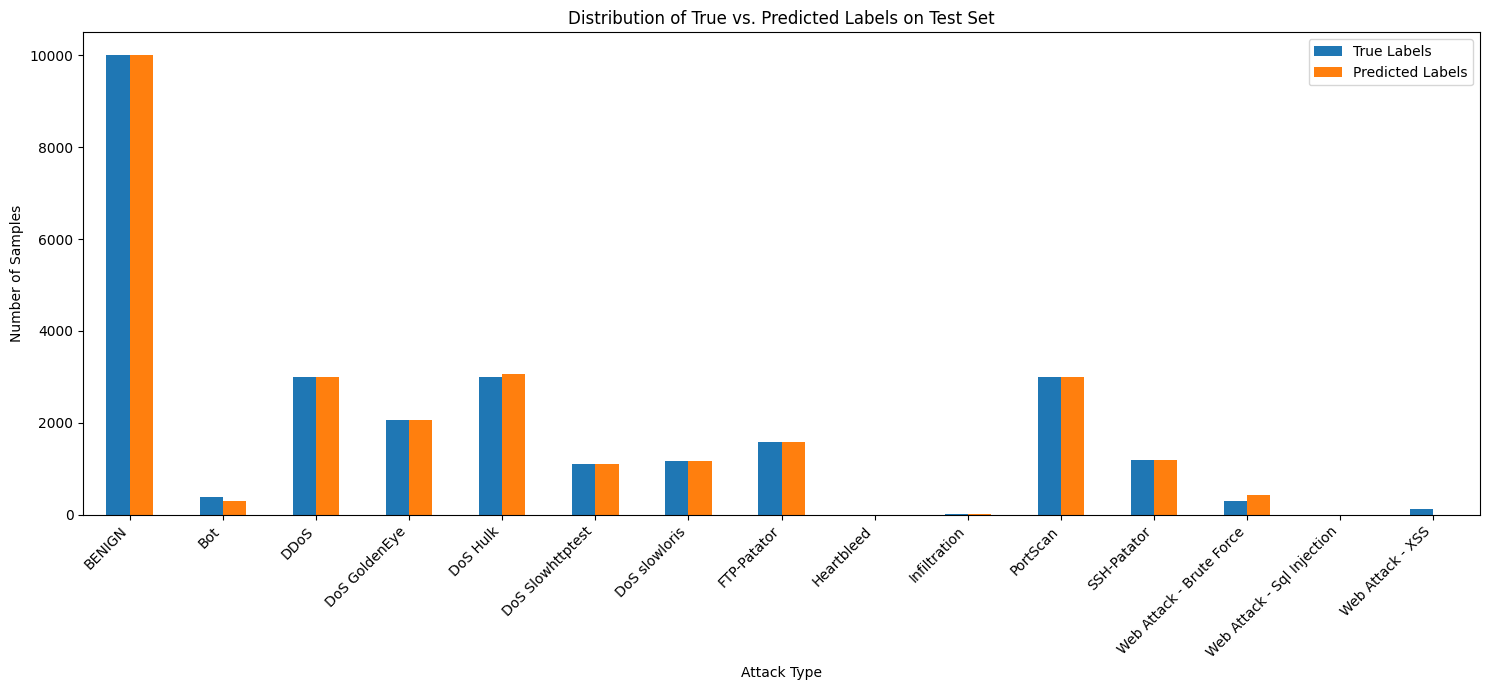

In [29]:
# 99.72%
import matplotlib.pyplot as plt
import pandas as pd

# Get true label distribution
true_label_counts = pd.Series(y_test).map(lambda x: label_encoder.classes_[x]).value_counts().sort_index()

# Get predicted label distribution
predicted_label_counts = pd.Series(y_pred_classes).map(lambda x: label_encoder.classes_[x]).value_counts().sort_index()

# Combine for easier plotting (aligning indices)
combined_counts = pd.DataFrame({
    'True Labels': true_label_counts,
    'Predicted Labels': predicted_label_counts
}).fillna(0)

# Plotting
plt.figure(figsize=(15, 7))
combined_counts.plot(kind='bar', figsize=(15, 7))
plt.title('Distribution of True vs. Predicted Labels on Test Set')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Saving Files

In [30]:
import tensorflow as tf

# Save the trained CNN model in native Keras format
model.save("/content/drive/MyDrive/IDS_model.keras")
print("Saved to Google Drive.")

Saved to Google Drive.


In [31]:
import joblib

# Save the label encoder
joblib.dump(label_encoder, "/content/drive/MyDrive/label_encoder_final.save")
print("Label Encoder saved to Google Drive.")

Label Encoder saved to Google Drive.


#END OF CODE

# Deployment

In [ ]:
# Streamlit installation
import sys
!{sys.executable} -m pip install streamlit

print("Streamlit installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.7 MB/s eta 0:00:00
Streamlit installed.


In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd

# Load the saved CNN model
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/IDS_model.keras')

# Load the scaler
loaded_scaler = joblib.load('/content/drive/MyDrive/scaler.save')

# Load the label encoder
loaded_label_encoder = joblib.load('/content/drive/MyDrive/label_encoder_full.save')

# Streamlit App
st.title('Network Intrusion Detection System (NIDS) CNN Model')
st.write('Upload a CSV file containing network traffic features for intrusion detection.')

uploaded_file = st.file_uploader('Choose a CSV file', type='csv')

if uploaded_file is not None:
    try:
        # Read the uploaded CSV file
        input_df = pd.read_csv(uploaded_file)
        st.write('Uploaded Data Preview:')
        st.write(input_df.head())

        # Preprocess the input data
        # Ensure columns are in the same order as the training data (assuming `X` was the original DataFrame)
        # For simplicity, we'll assume the uploaded CSV has the same columns and order as the training data.
        # In a real application, you'd need more robust column handling (e.g., reordering, handling missing/extra columns).

        # Scale the features
        input_scaled = loaded_scaler.transform(input_df.values)

        # Reshape for CNN model (add channel dimension)
        input_cnn = input_scaled.reshape(input_scaled.shape[0], input_scaled.shape[1], 1)

        # Make predictions
        predictions = loaded_model.predict(input_cnn)
        predicted_classes_encoded = np.argmax(predictions, axis=1)
        predicted_labels = loaded_label_encoder.inverse_transform(predicted_classes_encoded)

        st.write('Prediction Results:')
        result_df = input_df.copy()
        result_df['Predicted_Attack_Type'] = predicted_labels
        st.write(result_df[['Flow Duration', 'Destination Port', 'Predicted_Attack_Type']].head())

        # Display value counts for predicted labels
        st.write('Predicted Attack Type Distribution:')
        st.write(pd.Series(predicted_labels).value_counts())

    except Exception as e:
        st.error(f'Error processing file: {e}')

Overwriting app.py


First, we will start the Streamlit application. Instead of `streamlit run app.py`, which sometimes encounters path issues in Colab, we'll use `python -m streamlit run app.py`.

In [ ]:
import subprocess
import sys

# Run the Streamlit app in the background
# Using 'python -m streamlit' explicitly calls the module
# The --server.port argument is crucial for ngrok to tunnel to the correct port
process = subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.port', '8501', '--server.enableCORS', 'False', '--server.enableXsrfProtection', 'False'])

print("Streamlit app is running in the background on port 8501.")
print("Next, we'll set up ngrok to create a public URL for this app.")

Streamlit app is running in the background on port 8501.
Next, we'll set up ngrok to create a public URL for this app.


Now, to make your Streamlit app accessible via a public URL, you'll need to set up `ngrok`. If you haven't already, you'll need an ngrok authentication token.

1.  **Visit ngrok website**: Go to [ngrok.com](https://ngrok.com/) and sign up for a free account if you don't have one.
2.  **Obtain Auth Token**: Log in to your ngrok dashboard and navigate to the 'Your Authtoken' section (usually found under 'Setup & Installation'). Copy your authentication token.
3.  **Set Auth Token**: Execute the following cell, replacing `<YOUR_NGROK_AUTH_TOKEN>` with your actual token.

In [ ]:
from pyngrok import ngrok

# Replace <YOUR_NGROK_AUTH_TOKEN> with your actual token
ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN_HERE") # IMPORTANT: Replace this with your actual ngrok token

print("ngrok authentication token set.")

In [ ]:
from pyngrok import ngrok

# Open a ngrok tunnel to the Streamlit app's port (8501)
public_url = ngrok.connect(addr='8501', proto='http')

print(f"Public URL: {public_url}")
print("You can access your Streamlit app via this URL. Keep this Colab tab open for the tunnel to remain active.")

In [ ]:
import subprocess
import sys

# Run the Streamlit app in the background
# The --server.port argument is crucial for ngrok to tunnel to the correct port
process = subprocess.Popen(['streamlit', '-m', 'run', 'app.py', '--server.port', '8501', '--server.enableCORS', 'False', '--server.enableXsrfProtection', 'False'])

print("Streamlit app is running. You might need to expose the port using ngrok or similar for external access.")
print("To stop the app, interrupt this kernel or kill the process manually.")


FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'

In [ ]:

import sys
!{sys.executable} -m pip install pyngrok

print("pyngrok installed.")

pyngrok installed.


In [ ]:
from pyngrok import ngrok

# Replace <YOUR_NGROK_AUTH_TOKEN> with your actual token
ngrok.set_auth_token("3BdK21YaWdL8BHIjJsTopEuv2re_6Kmnwk9s6RQ6fR8bRH48p")

print("ngrok authentication token set.")

ngrok authentication token set.


Creating an ngrok tunnel to expose the Streamlit application running on port 8501 to a public URL.


In [ ]:
ngrok.kill()

In [ ]:
from pyngrok import ngrok

# Open a ngrok tunnel to the Streamlit app's port
public_url = ngrok.connect(addr='8501', proto='http')

print(f"Public URL: {public_url}")
print("You can access your Streamlit app via this URL.")

Public URL: NgrokTunnel: "https://preinstructional-dannie-ungravely.ngrok-free.dev" -> "http://localhost:8501"
You can access your Streamlit app via this URL.


In [ ]:
import pandas as pd
import os

# Reload data if not already in memory (or ensure 'data' is the full dataset)
# Assuming 'data' DataFrame from previous cells is available and correct

# Define target counts for diversity
sample_counts = {
    'BENIGN': 50000,
    'DoS Hulk': 10000,
    'PortScan': 10000,
    'DDoS': 10000,
    'DoS GoldenEye': 10000,
    'FTP-Patator': 7000,
    'SSH-Patator': 5000,
    'DoS slowloris': 5000,
    'DoS Slowhttptest': 5000,
    'Bot': 1500,
    'Web Attack - Brute Force': 1000,
    'Web Attack - XSS': 500,
    'Infiltration': 30,
    'Web Attack - Sql Injection': 20,
    'Heartbleed': 10
}

sampled_dfs = []

# Sample each class
for label, count in sample_counts.items():
    class_data = data[data['Label'] == label]
    # If the class has fewer samples than requested, take all of them
    n_samples = min(count, len(class_data))
    if n_samples > 0:
        sampled_dfs.append(class_data.sample(n=n_samples, random_state=42))
    else:
        print(f"Warning: Class '{label}' has no samples available in the dataset.")

# Concatenate all sampled DataFrames
diverse_sampled_df = pd.concat(sampled_dfs, ignore_index=True)

# Drop the 'Label' column as it is the target for prediction in the app
X_diverse_for_app = diverse_sampled_df.drop(columns=['Label'])

# Define the path for the new diverse sampled CSV file
diverse_sampled_csv_path = '/content/drive/MyDrive/CICIDS2017_diverse_sample_for_app.csv'

# Save the diverse DataFrame to CSV
X_diverse_for_app.to_csv(diverse_sampled_csv_path, index=False)

print(f"Diverse sampled CSV file created at: {diverse_sampled_csv_path}")
print(f"Shape of the diverse sampled data: {X_diverse_for_app.shape}")

# Verify the size of the new file
if os.path.exists(diverse_sampled_csv_path):
    file_size_bytes = os.path.getsize(diverse_sampled_csv_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    print(f"Size of the diverse sampled file: {file_size_mb:.2f} MB")
else:
    print(f"Error: Diverse sampled file not found at '{diverse_sampled_csv_path}'.")


Diverse sampled CSV file created at: /content/drive/MyDrive/CICIDS2017_diverse_sample_for_app.csv
Shape of the diverse sampled data: (113540, 78)
Size of the diverse sampled file: 37.11 MB


### Create a sampled CSV file without the 'Label' column for Streamlit app

In [ ]:
import pandas as pd
import os

# Drop the 'Label' column as it is the target for prediction
X_for_app = data.drop(columns=['Label'])

# Take a smaller sample, e.g., the first 100,000 rows
sampled_df_for_app = X_for_app.head(100000)

# Define the path for the new sampled CSV file
sampled_csv_path = '/content/drive/MyDrive/CICIDS2017_sample_for_app.csv'

# Save the sampled DataFrame to CSV
sampled_df_for_app.to_csv(sampled_csv_path, index=False)

print(f"Sampled CSV file created at: {sampled_csv_path}")
print(f"Shape of the sampled data: {sampled_df_for_app.shape}")

# Verify the size of the new file
if os.path.exists(sampled_csv_path):
    file_size_bytes = os.path.getsize(sampled_csv_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    print(f"Size of the sampled file: {file_size_mb:.2f} MB")
else:
    print(f"Error: Sampled file not found at '{sampled_csv_path}'.")

Sampled CSV file created at: /content/drive/MyDrive/CICIDS2017_sample_for_app.csv
Shape of the sampled data: (100000, 78)
Size of the sampled file: 31.06 MB


In [ ]:
import pandas as pd
import tensorflow as tf
import joblib
import numpy as np

# Load the main dataset
data = pd.read_csv('/content/drive/MyDrive/CICIDS2017.csv')
print("Main dataset loaded. Shape:", data.shape)

# Load the trained CNN model
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/CNN_IDS_model_full.keras')
print("Model loaded successfully.")

# Load the scaler
loaded_scaler = joblib.load('/content/drive/MyDrive/scaler.save')
print("Scaler loaded successfully.")

# Load the label encoder
loaded_label_encoder = joblib.load('/content/drive/MyDrive/label_encoder_full.save')
print("Label Encoder loaded successfully.")

# Re-initialize X and y, and prepare X_scaled (needed for sampling later if not yet done)
X = data.drop(columns=['Label'])
y = data['Label']

# Clean 'y' label if necessary (as done before)
y = y.str.replace("", "-", regex=False)

# Encode labels if not already encoded or if you need to recreate y_encoded
# This is important if you want to use y_encoded for further processing or if it's used in the Streamlit app internally
label_encoder = loaded_label_encoder # Assign the loaded encoder to the name used in previous cells
y_encoded = label_encoder.fit_transform(y)

# Scale features (X_scaled is used for model input)
X_scaled = loaded_scaler.transform(X.values)

print("All necessary data and preprocessing tools have been reloaded.")

Main dataset loaded. Shape: (2827876, 79)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully.
Scaler loaded successfully.
Label Encoder loaded successfully.
All necessary data and preprocessing tools have been reloaded.


### Check the size of the `CICIDS2017.csv` file

In [ ]:
import os

file_path = '/content/drive/MyDrive/CICIDS2017.csv'

if os.path.exists(file_path):
    file_size_bytes = os.path.getsize(file_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    print(f"The size of '{file_path}' is: {file_size_mb:.2f} MB")
else:
    print(f"File not found at '{file_path}'. Please ensure it was created correctly.")

The size of '/content/drive/MyDrive/CICIDS2017.csv' is: 918.13 MB




### Data Analysis Key Findings
*   A plot comparing training accuracy and validation accuracy over epochs was successfully generated to help identify overfitting or underfitting trends.
*   A plot illustrating training loss against validation loss over epochs was successfully generated to provide insights into the model's learning progression.
*   A heatmap of the confusion matrix was successfully generated, offering a visual overview of the model's classification performance by highlighting correctly and incorrectly classified instances for each class.
*   A bar chart comparing the distribution of true and predicted labels on the test set was successfully generated, which is intended to help uncover potential biases in the model's predictions across different classes, particularly for minority classes.





Save the current `label_encoder` object (which was used to encode the labels for the model that achieved 99.72% accuracy) to Google Drive using `joblib`. This ensures that the attack labels can be consistently decoded when the best-performing model is loaded for future predictions.


In [ ]:
# 98.75%
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(label_encoder.classes_)

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.1),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 76, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 36, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,447 (1.29 MB)

 Trainable params: 338,447 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 98.75%
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-5
)

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - accuracy: 0.9737 - loss: 0.0655 - val_accuracy: 0.9813 - val_loss: 0.0440 - learning_rate: 0.0100
Epoch 2/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9809 - loss: 0.0495 - val_accuracy: 0.9843 - val_loss: 0.0446 - learning_rate: 0.0100
Epoch 3/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9811 - loss: 0.0489 - val_accuracy: 0.9838 - val_loss: 0.0405 - learning_rate: 0.0100
Epoch 4/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9826 - loss: 0.0472 - val_accuracy: 0.9832 - val_loss: 0.0456 - learning_rate: 0.0100
Epoch 5/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9827 - loss: 0.0478 - val_accuracy: 0.9856 - val_loss: 0.0392 - learning_rate: 0.0100
Epoch 6/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9830 - loss: 0.0475 - val_accuracy: 0.9840 - val_loss: 0.0393 - learning_rate: 0.0100
Epoch 7/30
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 98.75%
Test Loss: 0.0339


In [ ]:
# 98.75%
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))


17675/17675 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    454265
                       Bot       0.99      0.38      0.55       391
                      DDoS       1.00      0.99      1.00     25605
             DoS GoldenEye       0.98      0.95      0.96      2059
                  DoS Hulk       0.99      0.99      0.99     46025
          DoS Slowhttptest       0.90      0.90      0.90      1100
             DoS slowloris       0.99      0.99      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.90      0.96      0.93     31761
               SSH-Patator       0.93      0.98      0.96      1180
  Web Attack - Brute Force       0.82      0.10      0.18       301
W

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


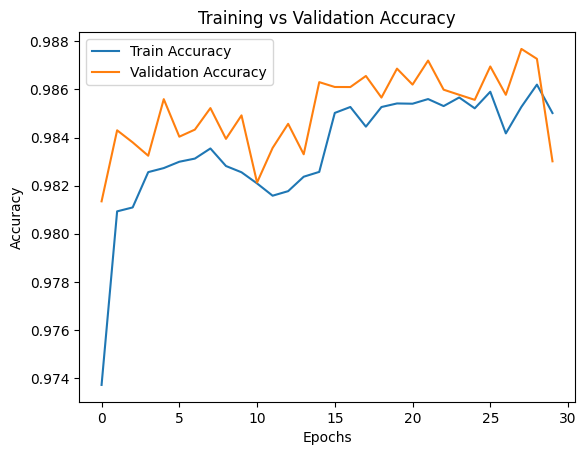

In [ ]:
# 98.75%
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


### Load the saved model and preprocessing steps

In [ ]:
# 98.75%
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd

# Load the saved CNN model
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/CNN_IDS_model_full.keras")
print("Model loaded successfully.")

# Load the scaler
loaded_scaler = joblib.load("/content/drive/MyDrive/scaler.save")
print("Scaler loaded successfully.")

# Load the label encoder
loaded_label_encoder = joblib.load("/content/drive/MyDrive/label_encoder_full.save")
print("Label Encoder loaded successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully.
Scaler loaded successfully.
Label Encoder loaded successfully.


In [ ]:
# 98.75%
import joblib

joblib.dump(scaler, "/content/drive/MyDrive/scaler.save")
joblib.dump(label_encoder, "/content/drive/MyDrive/label_encoder.save")

print("Scaler and Label Encoder saved to Google Drive")

Scaler and Label Encoder saved to Google Drive


In [ ]:
# Dropout and Learning Rate Changed
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(label_encoder.classes_)

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3), # Changed dropout rate from 0.1 to 0.3

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001), # Learning rate changed from 0.1 to 0.001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 76, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 36, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,935 (1.23 MB)

 Trainable params: 321,935 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Dropout and Learning Rate Changed
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-5
)

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7592 - loss: 0.8079 - val_accuracy: 0.9524 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 2/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9440 - loss: 0.1844 - val_accuracy: 0.9530 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 3/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9565 - loss: 0.1372 - val_accuracy: 0.9597 - val_loss: 0.1501 - learning_rate: 0.0010
Epoch 4/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9610 - loss: 0.1199 - val_accuracy: 0.9681 - val_loss: 0.1329 - learning_rate: 0.0010
Epoch 5/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9633 - loss: 0.1082 - val_accuracy: 0.9649 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 6/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9642 - loss: 0.1048 - val_accuracy: 0.9697 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 7/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9656 - loss: 0.0992 -

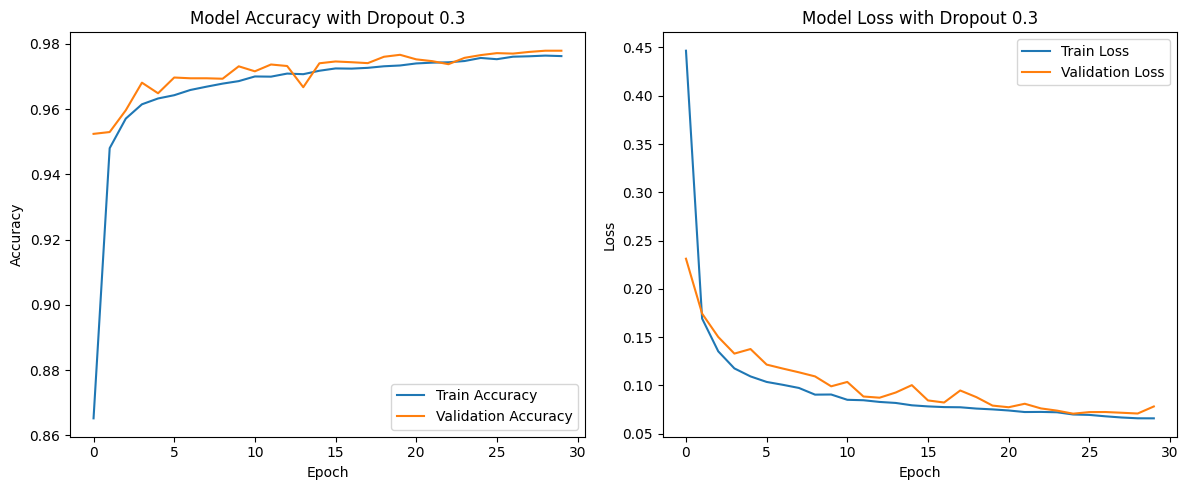

In [ ]:
# Dropout and Learning Rate Changed
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy with Dropout 0.3')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss with Dropout 0.3')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Analysis of Training Graphs with Dropout 0.3


**Training vs Validation Accuracy Plot:**

*   **Observation**: Both training and validation accuracy show a consistent upward trend. The validation accuracy closely follows the training accuracy, and the gap between them is relatively small. Towards the end of training, both metrics appear to be converging or have converged at a high level.
*   **Interpretation**: This indicates good model learning and generalization. The smaller gap between training and validation accuracy, compared to the previous run, suggests that the reduced dropout rate (0.3) has helped in mitigating overfitting. The model is learning effectively from the training data and performing well on unseen validation data.

**Training vs Validation Loss Plot:**

*   **Observation**: Both training and validation loss decrease steadily over epochs. The validation loss curve is smooth and does not show a significant increase or plateauing trend that would indicate strong overfitting.
*   **Interpretation**: The synchronized decrease in both training and validation loss is a positive sign, indicating that the model is learning efficiently without memorizing the training data. The dropout rate of 0.3 seems to have improved the model's ability to generalize, as evidenced by the stable validation loss. This configuration appears to strike a better balance between bias and variance compared to the previous run with a dropout rate of 0.5.

#EXPERIMENTATION

### Analysis of Training History with Learning Rate 0.005

**Training vs Validation Accuracy Plot (referring to the plot that would be generated):**

*   **Observation**: The training accuracy (`accuracy`) starts relatively lower but increases rapidly in the initial epochs. The validation accuracy (`val_accuracy`) also increases, but it shows significant fluctuations and starts to diverge from the training accuracy after a few epochs. It reaches a peak and then becomes more volatile. The model achieved a `val_accuracy` of around 97.7%-97.9% after dropping the learning rate, which is an improvement compared to the ~96% initial range but less stable than with a lower learning rate.
*   **Interpretation**: The rapid increase in training accuracy indicates faster learning due to the higher learning rate. However, the larger gap and increased volatility between training and validation accuracy, especially after the initial epochs, are strong indicators of **overfitting**. The model is quickly memorizing the training data, but this aggressive learning is causing it to perform less consistently on unseen validation data. The `ReduceLROnPlateau` callback effectively reduced the learning rate when `val_loss` plateaued, which helped to stabilize the accuracy somewhat towards the later epochs.

**Training vs Validation Loss Plot (referring to the plot that would be generated):**

*   **Observation**: The training loss (`loss`) decreases quickly. The validation loss (`val_loss`) also decreases initially but then starts to increase significantly and become erratic. It exhibits much more instability compared to the previous run with a lower learning rate. Even after the learning rate reduction by `ReduceLROnPlateau`, the `val_loss` remains higher and more erratic than ideal.
*   **Interpretation**: The divergence and instability in the validation loss heavily suggest that the increased initial learning rate of 0.005 was too aggressive, leading to overfitting. While a higher learning rate can speed up convergence, in this case, it caused the model to overshoot optimal weights and struggle to generalize. The `EarlyStopping` callback likely prevented severe overfitting by restoring the best weights, but the overall training dynamics show that this learning rate was not ideal for stable generalization.

### Analysis of Training History

**Training vs Validation Accuracy Plot (from previous output):**

*   **Observation**: The training accuracy (`Train Accuracy`) shows a general upward trend, indicating that the model is learning from the training data. The validation accuracy (`Validation Accuracy`) also shows an upward trend and closely follows the training accuracy, but it appears to plateau or show minor fluctuations after a certain number of epochs.
*   **Interpretation**: If the training accuracy continues to improve significantly while the validation accuracy plateaus or starts to decrease, it would suggest overfitting. In this case, while there's a slight gap, the validation accuracy remains high and stable, suggesting the model generalizes reasonably well, but there might be a hint of potential overfitting as the training accuracy slightly outperforms the validation accuracy. The model has achieved a high accuracy on both sets.

**Training vs Validation Loss Plot (generated in the previous step):**

*   **Observation**: The training loss (`Train Loss`) consistently decreases over epochs. The validation loss (`Validation Loss`) also decreases initially but then starts to plateau and even slightly increase towards the later epochs, though the increase is minimal.
*   **Interpretation**: A decreasing training loss combined with a validation loss that starts to increase is a strong indicator of overfitting. The model is becoming too specialized to the training data and performs less optimally on unseen (validation) data. Although the increase in validation loss is not dramatic, it suggests that the model is beginning to overfit the training data. The `early_stop` callback likely helped to mitigate severe overfitting by restoring the best weights.

#-----------------------------------------------------------------------------------